# Acte 1 — Le monde 🧠 Mini World Model — V3 (physique explicite)

Dans cette version, on restructure complètement la génération du dataset.

## 🎯 Objectif

Apprendre un **modèle du monde** (world model) capable de prédire :

> état + action → état suivant

---

## ⚠️ Problème des versions précédentes

Jusqu’ici, le dataset était généré principalement par des rollouts aléatoires.

➡️ Résultat :
- beaucoup de transitions peu informatives
- peu de cas critiques (collision, blocage, etc.)
- apprentissage moins structuré

---

## ✅ Approche V3

On définit explicitement les **lois physiques du monde** :

- déplacement libre de l’agent
- blocage par les murs
- poussée de la boîte
- boîte bloquée contre mur
- boîte bloquée sur la cible

Puis on construit un dataset qui expose volontairement ces situations.

---

## 💡 Idée clé

> Le modèle n’apprend bien que ce qu’on lui montre clairement.

Donc :
- moins de hasard
- plus de cas dirigés
- meilleure couverture des règles du monde

---

## 🧩 Pipeline

1. Définir les règles
2. Générer des transitions dirigées
3. Construire un dataset équilibré
4. Sauvegarder pour l'entraînement

---

👉 On commence par visualiser et tester les règles physiques.

## Imports

In [1]:
import sys
import os

# ajouter le dossier parent au path
sys.path.append(os.path.abspath(".."))

In [2]:
# === Imports ===

import sys
import os

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from environment import GridWorld

# affichage plus propre
plt.rcParams["figure.figsize"] = (4, 4)
plt.rcParams["image.cmap"] = "gray"

# seed
np.random.seed(42)

# env
env = GridWorld(size=10)

print("Environment initialisé ✔️")

Environment initialisé ✔️


## 1. L'environnement — GridWorld

Le monde est une grille 10×10. Les bords sont des murs fixes.
À l'intérieur, trois objets mobiles : l'agent, la boîte, la cible.

L'état du monde à chaque instant est représenté par une image 10×10
où chaque pixel encode la présence d'un objet :

- 0.0 → case vide (blanc)
- 0.3 → mur (gris foncé)
- 0.5 → agent (gris)
- 0.8 → boîte (rouge)
- 1.0 → cible (vert)

La classe `GridWorld` gère :
- l'initialisation du monde
- le rendu en image
- les règles de transition (déplacement, poussée, collision)

**Note sur l'initialisation** : la boîte est toujours placée dans
l'intérieur profond de la grille (loin des murs) pour garantir
la diversité du dataset — une boîte collée dès le départ au mur
ne pourrait plus jamais bouger.

## 2. Utilitaires de visualisation

`grid_to_rgb` est la fonction centrale de rendu : elle convertit
une grille 10×10 en image RGB. Toutes les autres fonctions
de visualisation l'appellent — si on veut changer une couleur,
on le fait ici, une seule fois.

In [3]:
import matplotlib.patches as patches


def grid_to_rgb(grid):
    """
    Convertit une grille 10×10 (valeurs flottantes) en image RGB.
    Centralise le mapping valeur -> couleur.
    """
    rgb = np.zeros((grid.shape[0], grid.shape[1], 3), dtype=np.float64)

    rgb[grid == GridWorld.EMPTY] = [1.0, 1.0, 1.0]
    rgb[grid == GridWorld.WALL] = [0.3, 0.3, 0.3]
    rgb[grid == GridWorld.AGENT] = [0.2, 0.4, 0.9]
    rgb[grid == GridWorld.BOX] = [0.9, 0.2, 0.2]
    rgb[grid == GridWorld.TARGET] = [0.2, 0.8, 0.2]
    rgb[grid == GridWorld.BOX_ON_TARGET] = [0.9, 0.6, 0.0]
    rgb[grid == GridWorld.AGENT_ON_TARGET] = [0.4, 0.2, 0.9]

    return rgb


def show_grid_color(grid, title=""):
    """
    Affiche une grille en couleurs avec légende.
    """
    rgb = grid_to_rgb(grid)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(rgb)
    ax.set_title(title)
    ax.axis("off")

    legend = [
        patches.Patch(color=[0.3, 0.3, 0.3], label="mur"),
        patches.Patch(color=[0.2, 0.4, 0.9], label="agent"),
        patches.Patch(color=[0.9, 0.2, 0.2], label="boîte"),
        patches.Patch(color=[0.2, 0.8, 0.2], label="cible"),
        patches.Patch(color=[0.9, 0.6, 0.0], label="boîte sur cible"),
        patches.Patch(color=[0.4, 0.2, 0.9], label="agent sur cible"),
    ]
    ax.legend(handles=legend, loc="upper right",
              bbox_to_anchor=(1.55, 1), fontsize=8)

    plt.tight_layout()
    plt.show()


def show_transition(obs, next_obs, action_name=""):
    """
    Affiche côte à côte un état et l'état suivant.
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(grid_to_rgb(obs))
    axes[0].set_title("État courant")
    axes[0].axis("off")

    axes[1].imshow(grid_to_rgb(next_obs))
    axes[1].set_title(f"État suivant ({action_name})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## 🧪 Visualisation du monde

Avant de générer un dataset, on vérifie que notre environnement fonctionne correctement.

On visualise :

- un état aléatoire (`reset`)
- un état contrôlé (`set_state`)

👉 Objectif :
- comprendre visuellement la structure du monde
- vérifier que le rendu est cohérent
- préparer les tests des règles physiques

---

💡 Rappel :

Une observation est une grille 10×10 contenant :
- les murs (bordures)
- l’agent
- la boîte
- la cible

Cette grille est l’entrée du modèle.

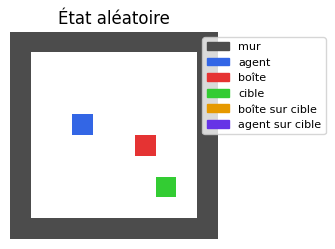

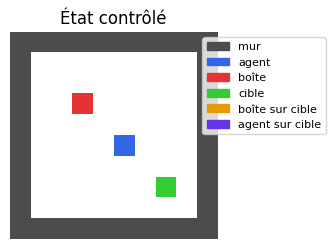

In [4]:
# === État aléatoire ===

env.reset()
obs = env.render()

show_grid_color(obs, title="État aléatoire")


# === État contrôlé ===

env.set_state(
    agent=(5, 5),
    box=(3, 3),
    target=(7, 7)
)

obs = env.render()

show_grid_color(obs, title="État contrôlé")

## ⚙️ Tests des lois physiques

Avant de générer un dataset dirigé, on vérifie explicitement chaque règle du monde.

On construit des situations simples et contrôlées pour observer :

1. déplacement libre
2. agent bloqué par un mur
3. poussée valide de la boîte
4. boîte bloquée par un mur
5. boîte bloquée sur la cible

👉 Objectif :
- vérifier que la physique du monde correspond bien à notre design
- rendre les transitions lisibles visuellement
- préparer la génération d'exemples informatifs

In [5]:
ACTION_NAMES = {
    0: "haut",
    1: "bas",
    2: "gauche",
    3: "droite",
}


def run_case(agent, box, target, action, title=""):
    """
    Construit un cas contrôlé, exécute une action, et affiche la transition.
    """
    env.set_state(agent=agent, box=box, target=target)
    obs = env.render().copy()
    next_obs = env.step(action).copy()

    print(title)
    print("État initial :", {"agent": agent, "box": box, "target": target})
    print("Action :", ACTION_NAMES[action])

    show_transition(obs, next_obs, action_name=ACTION_NAMES[action])

### 1. Déplacement libre

Si l'agent avance vers une case vide, il se déplace normalement.
La boîte et la cible ne changent pas.

Cas 1 — déplacement libre
État initial : {'agent': (5, 5), 'box': (3, 3), 'target': (7, 7)}
Action : droite


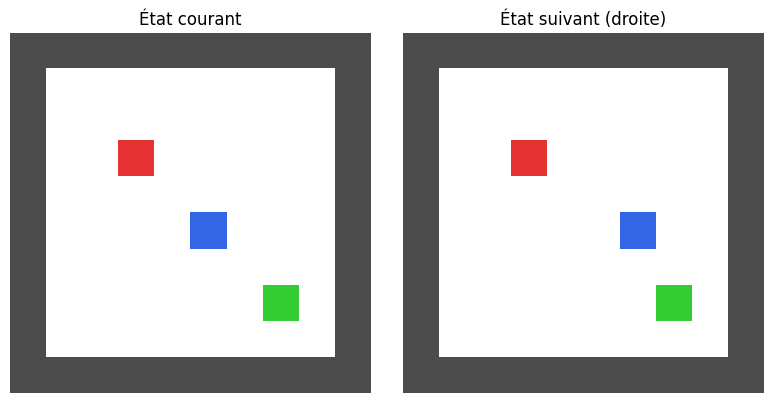

In [6]:
run_case(
    agent=(5, 5),
    box=(3, 3),
    target=(7, 7),
    action=3,  # droite
    title="Cas 1 — déplacement libre"
)

### 2. Agent bloqué par un mur

Si l'agent tente d'aller dans un mur, rien ne bouge.
C'est une transition importante, car elle apprend au modèle qu'une action
n'a pas toujours d'effet.

Cas 2 — agent bloqué par un mur
État initial : {'agent': (1, 5), 'box': (3, 3), 'target': (7, 7)}
Action : haut


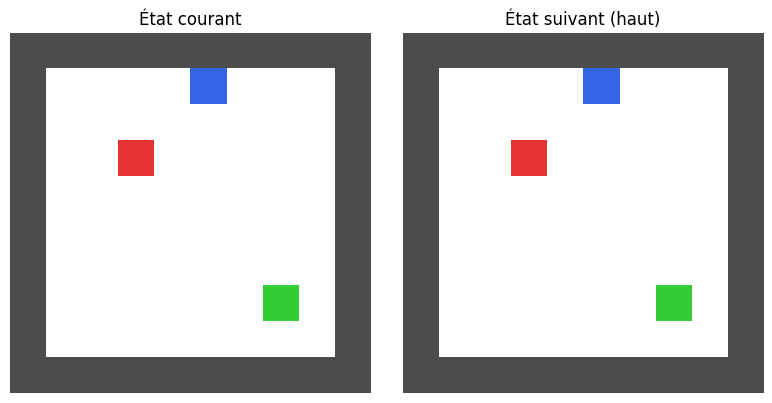

In [7]:
run_case(
    agent=(1, 5),
    box=(3, 3),
    target=(7, 7),
    action=0,  # haut
    title="Cas 2 — agent bloqué par un mur"
)

### 3. Poussée valide

Si l'agent pousse la boîte et que la case derrière la boîte est libre,
alors :
- la boîte avance d'une case
- l'agent prend l'ancienne place de la boîte

Cas 3 — poussée valide
État initial : {'agent': (5, 4), 'box': (5, 5), 'target': (7, 7)}
Action : droite


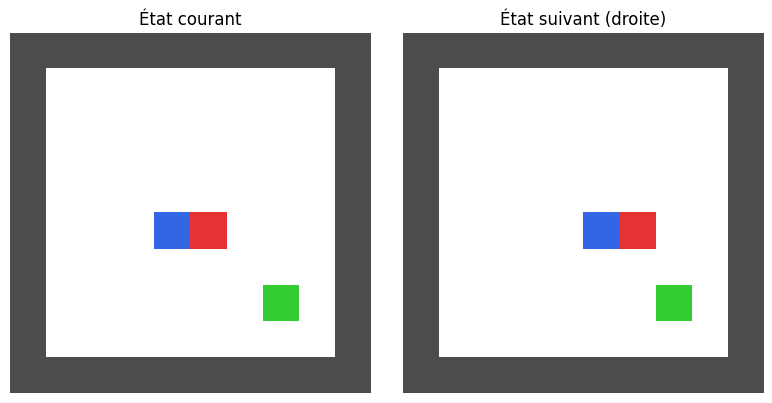

In [8]:
run_case(
    agent=(5, 4),
    box=(5, 5),
    target=(7, 7),
    action=3,  # droite
    title="Cas 3 — poussée valide"
)

### 4. Boîte bloquée par un mur

Si l'agent pousse une boîte alors qu'elle est déjà collée au mur
dans la direction de la poussée, rien ne bouge.

Cas 4 — boîte bloquée par un mur
État initial : {'agent': (2, 5), 'box': (1, 5), 'target': (7, 7)}
Action : haut


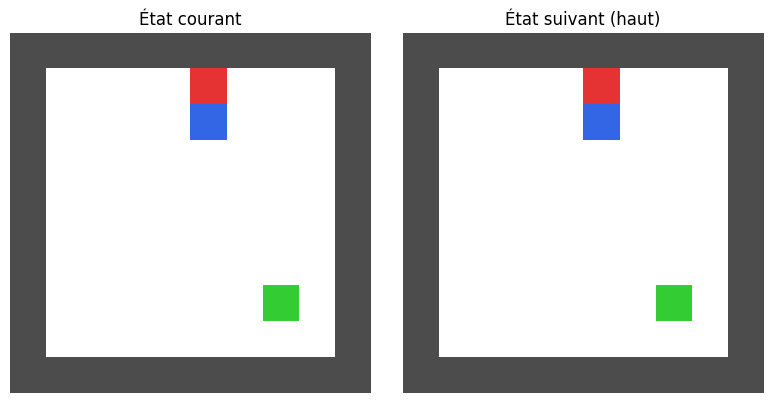

In [9]:
run_case(
    agent=(2, 5),
    box=(1, 5),
    target=(7, 7),
    action=0,  # haut
    title="Cas 4 — boîte bloquée par un mur"
)

### 5. Boîte bloquée sur la cible

Dans cette version V3, une boîte qui atteint la cible devient immobile.

Si l'agent pousse une boîte déjà posée sur la cible, rien ne bouge.
La cible devient donc un véritable élément de la physique du monde.

Cas 5 — boîte bloquée sur la cible
État initial : {'agent': (5, 4), 'box': (5, 5), 'target': (5, 5)}
Action : droite


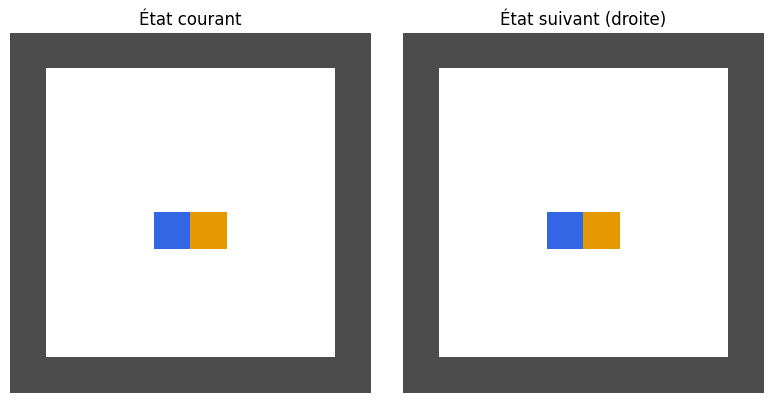

In [10]:
run_case(
    agent=(5, 4),
    box=(5, 5),
    target=(5, 5),
    action=3,  # droite
    title="Cas 5 — boîte bloquée sur la cible"
)

## ✅ Bilan intermédiaire

À ce stade, les règles physiques du monde sont explicites et validées visuellement.

Le notebook peut maintenant passer à l'étape suivante :

👉 générer un dataset dirigé qui expose volontairement ces lois,
au lieu de dépendre principalement de rollouts aléatoires.

## 🏗️ Génération de cas dirigés

On veut maintenant construire un dataset **informatif**.

Au lieu de dépendre principalement de trajectoires aléatoires, on va générer
des transitions correspondant explicitement aux grandes lois physiques du monde :

- déplacement libre
- agent bloqué par un mur
- poussée valide
- boîte bloquée par un mur
- boîte bloquée sur la cible

Chaque fonction ci-dessous construit un état contrôlé, applique une action,
et retourne :

- l'observation courante
- l'action
- l'observation suivante
- le nom de la catégorie

👉 Cela nous permettra ensuite de composer un dataset équilibré.

In [11]:
# === Helpers géométriques ===

ACTION_TO_DELTA = {
    0: (-1, 0),  # haut
    1: (1, 0),   # bas
    2: (0, -1),  # gauche
    3: (0, 1),   # droite
}


def opposite_action(action):
    return {0: 1, 1: 0, 2: 3, 3: 2}[action]


def random_action():
    return np.random.randint(0, 4)


def random_interior_cell(size=10):
    r = np.random.randint(1, size - 1)
    c = np.random.randint(1, size - 1)
    return (r, c)


def random_interior_cell_excluding(excluded, size=10):
    excluded = set(excluded)
    while True:
        cell = random_interior_cell(size=size)
        if cell not in excluded:
            return cell

### Générateur 1 — Déplacement libre

On construit un état où l'agent peut avancer dans une direction donnée sans
rencontrer ni mur ni boîte.

In [12]:
def make_free_move_case(size=10):
    action = random_action()
    dr, dc = ACTION_TO_DELTA[action]

    # on choisit la case d'arrivée de l'agent de sorte qu'elle soit intérieure
    next_agent = (
        np.random.randint(1, size - 1),
        np.random.randint(1, size - 1)
    )

    # on déduit la position initiale de l'agent
    agent = (next_agent[0] - dr, next_agent[1] - dc)

    # vérification : agent doit aussi être dans l'intérieur
    if not (1 <= agent[0] < size - 1 and 1 <= agent[1] < size - 1):
        return make_free_move_case(size=size)

    # boîte et cible ailleurs
    box = random_interior_cell_excluding({agent, next_agent}, size=size)
    target = random_interior_cell_excluding({agent, next_agent, box}, size=size)

    env = GridWorld(size=size)
    env.set_state(agent=agent, box=box, target=target)

    obs = env.render().copy()
    next_obs = env.step(action).copy()

    return obs, action, next_obs, "free_move"

### Générateur 2 — Agent bloqué par un mur

On place l'agent contre un mur dans la direction de l'action.
La boîte et la cible sont ailleurs.

In [13]:
def make_agent_blocked_by_wall_case(size=10):
    action = random_action()

    if action == 0:      # haut
        agent = (1, np.random.randint(1, size - 1))
    elif action == 1:    # bas
        agent = (size - 2, np.random.randint(1, size - 1))
    elif action == 2:    # gauche
        agent = (np.random.randint(1, size - 1), 1)
    else:                # droite
        agent = (np.random.randint(1, size - 1), size - 2)

    box = random_interior_cell_excluding({agent}, size=size)
    target = random_interior_cell_excluding({agent, box}, size=size)

    env = GridWorld(size=size)
    env.set_state(agent=agent, box=box, target=target)

    obs = env.render().copy()
    next_obs = env.step(action).copy()

    return obs, action, next_obs, "agent_blocked_by_wall"

### Générateur 3 — Poussée valide

On place l'agent juste derrière la boîte, avec une case libre derrière la boîte
dans la direction de la poussée.

In [14]:
def make_valid_push_case(size=10):
    action = random_action()
    dr, dc = ACTION_TO_DELTA[action]

    # on choisit la position initiale de la boîte de sorte qu'elle puisse avancer
    box = (
        np.random.randint(2, size - 2),
        np.random.randint(2, size - 2)
    )

    next_box = (box[0] + dr, box[1] + dc)
    agent = (box[0] - dr, box[1] - dc)

    # il faut que agent et next_box soient intérieurs
    if not (1 <= agent[0] < size - 1 and 1 <= agent[1] < size - 1):
        return make_valid_push_case(size=size)
    if not (1 <= next_box[0] < size - 1 and 1 <= next_box[1] < size - 1):
        return make_valid_push_case(size=size)

    target = random_interior_cell_excluding({agent, box, next_box}, size=size)

    env = GridWorld(size=size)
    env.set_state(agent=agent, box=box, target=target)

    obs = env.render().copy()
    next_obs = env.step(action).copy()

    return obs, action, next_obs, "valid_push"

### Générateur 4 — Boîte bloquée par un mur

On place la boîte contre un mur dans la direction de la poussée, et l'agent
juste derrière elle.

In [15]:
def make_box_blocked_by_wall_case(size=10):
    action = random_action()

    if action == 0:      # haut
        box = (1, np.random.randint(1, size - 1))
        agent = (2, box[1])
    elif action == 1:    # bas
        box = (size - 2, np.random.randint(1, size - 1))
        agent = (size - 3, box[1])
    elif action == 2:    # gauche
        box = (np.random.randint(1, size - 1), 1)
        agent = (box[0], 2)
    else:                # droite
        box = (np.random.randint(1, size - 1), size - 2)
        agent = (box[0], size - 3)

    target = random_interior_cell_excluding({agent, box}, size=size)

    env = GridWorld(size=size)
    env.set_state(agent=agent, box=box, target=target)

    obs = env.render().copy()
    next_obs = env.step(action).copy()

    return obs, action, next_obs, "box_blocked_by_wall"

### Générateur 5 — Boîte bloquée sur la cible

On place la boîte directement sur la cible, et l'agent juste derrière.
Toute tentative de poussée doit échouer.

In [16]:
def make_box_on_target_blocked_case(size=10):
    action = random_action()
    dr, dc = ACTION_TO_DELTA[action]

    box = (
        np.random.randint(2, size - 2),
        np.random.randint(2, size - 2)
    )
    target = box
    agent = (box[0] - dr, box[1] - dc)

    if not (1 <= agent[0] < size - 1 and 1 <= agent[1] < size - 1):
        return make_box_on_target_blocked_case(size=size)

    env = GridWorld(size=size)
    env.set_state(agent=agent, box=box, target=target)

    obs = env.render().copy()
    next_obs = env.step(action).copy()

    return obs, action, next_obs, "box_on_target_blocked"

### Générateur 6 — Poussée sur la cible

On place la boîte juste devant la cible dans la direction de la poussée,
et l'agent juste derrière la boîte. La cible est donc `next_box`.

C'est la transition manquante : le moment où la boîte se verrouille sur la cible.

In [17]:
def make_push_onto_target_case(size=10):
    action = random_action()
    dr, dc = ACTION_TO_DELTA[action]

    # next_box sera la cible — on le choisit intérieur avec assez de marge
    # pour que box et agent soient aussi valides
    next_box = (
        np.random.randint(2, size - 2),
        np.random.randint(2, size - 2)
    )

    box = (next_box[0] - dr, next_box[1] - dc)   # boîte avant la poussée
    agent = (box[0] - dr, box[1] - dc)            # agent derrière la boîte
    target = next_box                              # la cible est là où la boîte va atterrir

    # vérifications de validité
    if not (1 <= box[0] < size - 1 and 1 <= box[1] < size - 1):
        return make_push_onto_target_case(size=size)
    if not (1 <= agent[0] < size - 1 and 1 <= agent[1] < size - 1):
        return make_push_onto_target_case(size=size)

    env = GridWorld(size=size)
    env.set_state(agent=agent, box=box, target=target)

    obs = env.render().copy()
    next_obs = env.step(action).copy()

    return obs, action, next_obs, "push_onto_target"

## 🔍 Vérification rapide des générateurs

Avant de produire un gros dataset, on vérifie visuellement qu'un exemple
de chaque catégorie correspond bien à la loi physique attendue.

Catégorie : free_move | Action : gauche


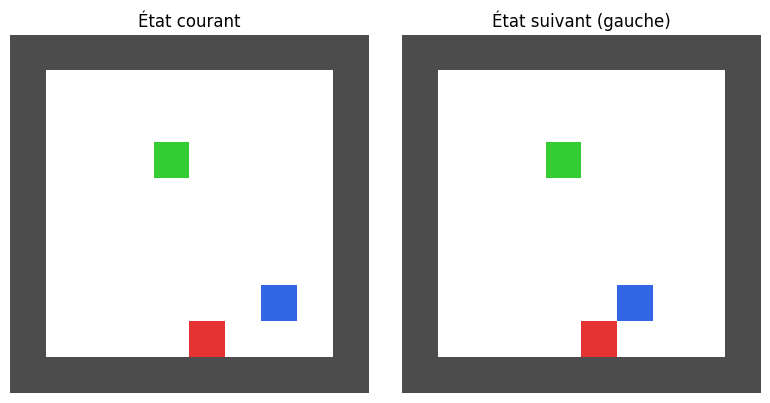

Catégorie : agent_blocked_by_wall | Action : droite


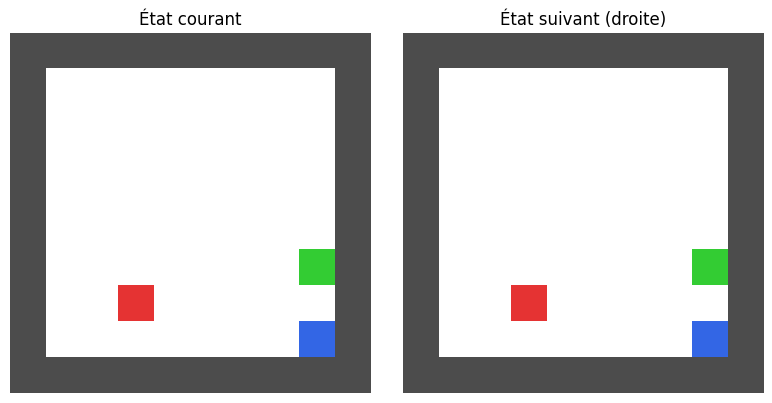

Catégorie : valid_push | Action : haut


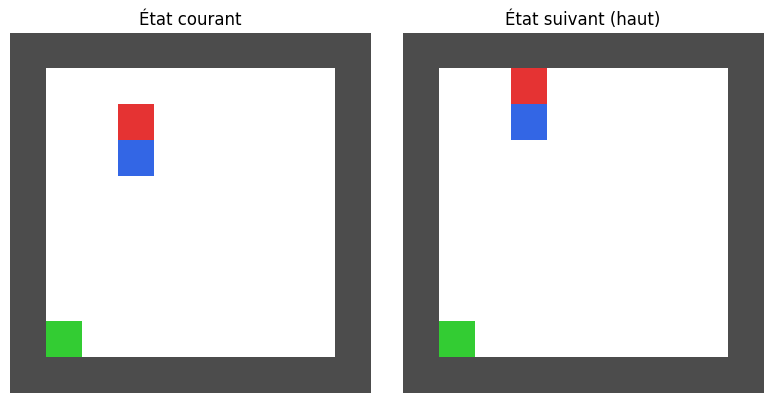

Catégorie : box_blocked_by_wall | Action : bas


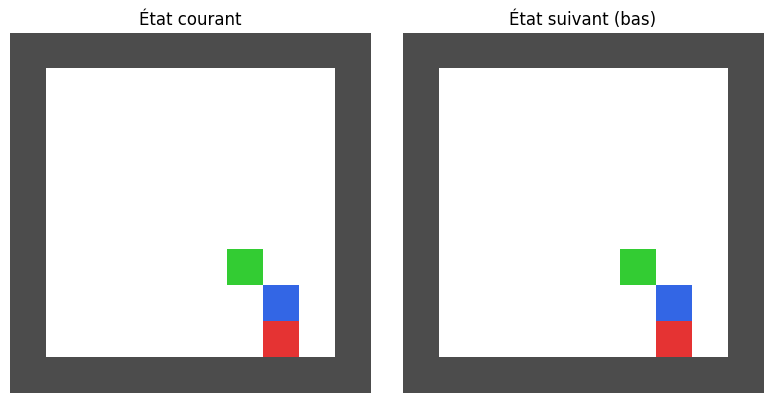

Catégorie : box_on_target_blocked | Action : haut


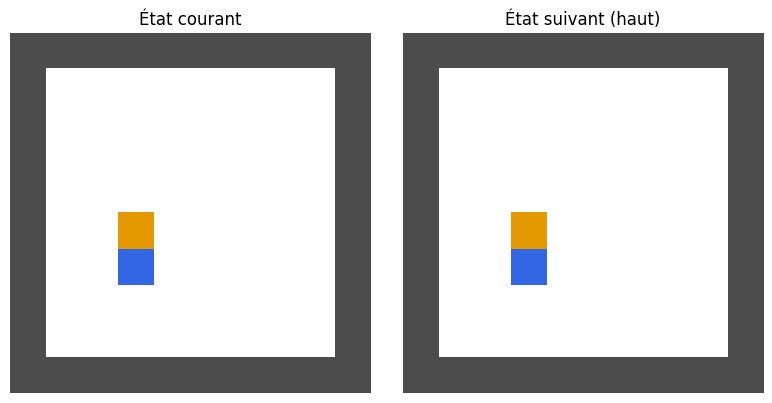

Catégorie : push_onto_target | Action : droite


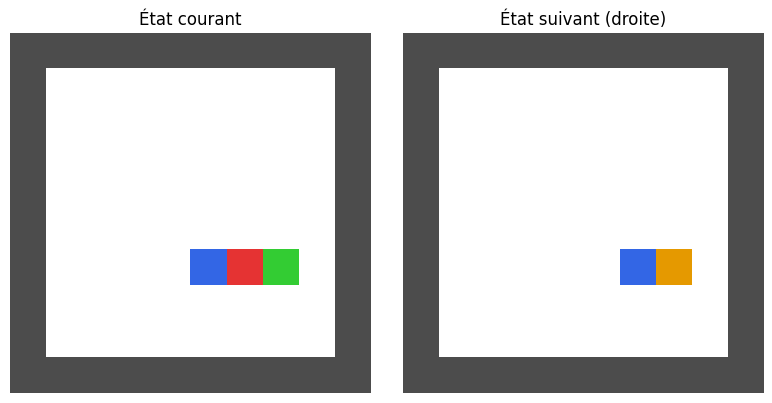

In [18]:
generators = [
    make_free_move_case,
    make_agent_blocked_by_wall_case,
    make_valid_push_case,
    make_box_blocked_by_wall_case,
    make_box_on_target_blocked_case,
    make_push_onto_target_case,
]

for gen in generators:
    obs, action, next_obs, category = gen(size=10)
    print("Catégorie :", category, "| Action :", ACTION_NAMES[action])
    show_transition(obs, next_obs, action_name=ACTION_NAMES[action])

## 🏗️ Construction du dataset dirigé

On assemble maintenant un dataset à partir des générateurs définis précédemment.

👉 Objectif :
- contrôler le nombre d'exemples par catégorie
- équilibrer les lois physiques
- produire un dataset plus informatif que du sampling aléatoire

Chaque transition contient :
- observation (state)
- action
- observation suivante (next_state)

On conserve aussi la catégorie pour analyse.

In [19]:
def generate_dataset(n_per_category=2000, size=10):
    observations = []
    actions = []
    next_observations = []
    categories = []

    generators = [
        make_free_move_case,
        make_agent_blocked_by_wall_case,
        make_valid_push_case,
        make_box_blocked_by_wall_case,
        make_box_on_target_blocked_case,
        make_push_onto_target_case,
    ]

    for gen in generators:
        print(f"Generating {gen.__name__}...")
        for _ in range(n_per_category):
            obs, action, next_obs, category = gen(size=size)

            observations.append(obs)
            actions.append(action)
            next_observations.append(next_obs)
            categories.append(category)

    observations = np.array(observations, dtype=np.float32)
    actions = np.array(actions, dtype=np.int64)
    next_observations = np.array(next_observations, dtype=np.float32)

    return observations, actions, next_observations, categories

## 🚀 Génération du dataset

On génère maintenant le dataset complet.

👉 Ajuste `n_per_category` selon :
- vitesse vs qualité
- taille mémoire

In [20]:
observations, actions, next_obs, categories = generate_dataset(
    n_per_category=4000,
    size=10
)

print("Dataset généré ✔️")
print("Shape observations :", observations.shape)
print("Shape actions :", actions.shape)
print("Shape next_obs :", next_obs.shape)

Generating make_free_move_case...
Generating make_agent_blocked_by_wall_case...
Generating make_valid_push_case...
Generating make_box_blocked_by_wall_case...
Generating make_box_on_target_blocked_case...
Generating make_push_onto_target_case...
Dataset généré ✔️
Shape observations : (24000, 10, 10)
Shape actions : (24000,)
Shape next_obs : (24000, 10, 10)


## 📊 Vérification de la distribution

On vérifie que le dataset est bien équilibré entre les catégories.

In [21]:
from collections import Counter

counter = Counter(categories)

for k, v in counter.items():
    print(f"{k}: {v}")

free_move: 4000
agent_blocked_by_wall: 4000
valid_push: 4000
box_blocked_by_wall: 4000
box_on_target_blocked: 4000
push_onto_target: 4000


## 🔍 Vérification qualitative

On visualise quelques transitions aléatoires du dataset.

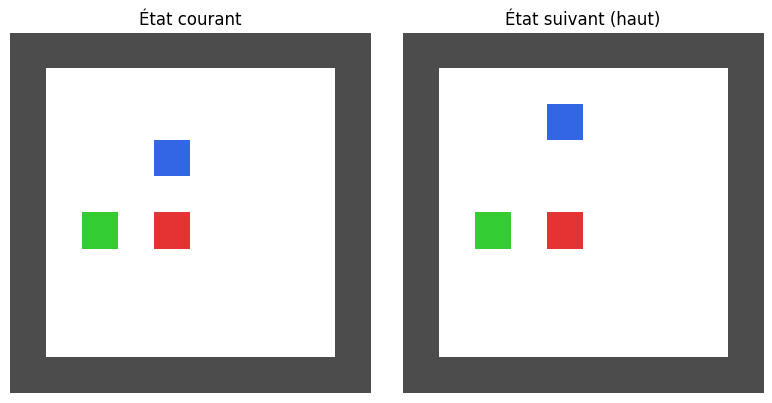

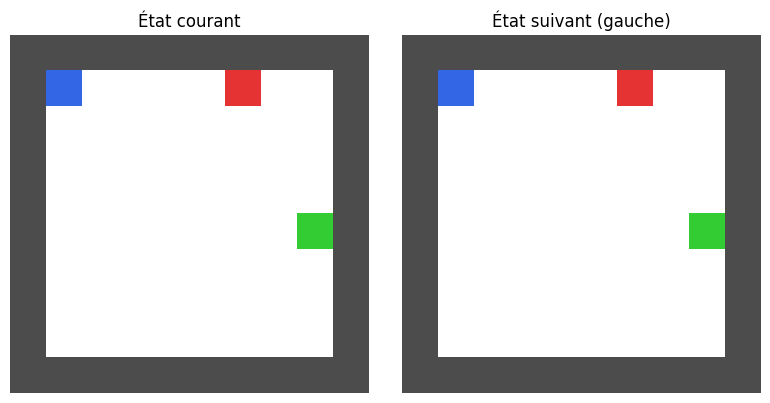

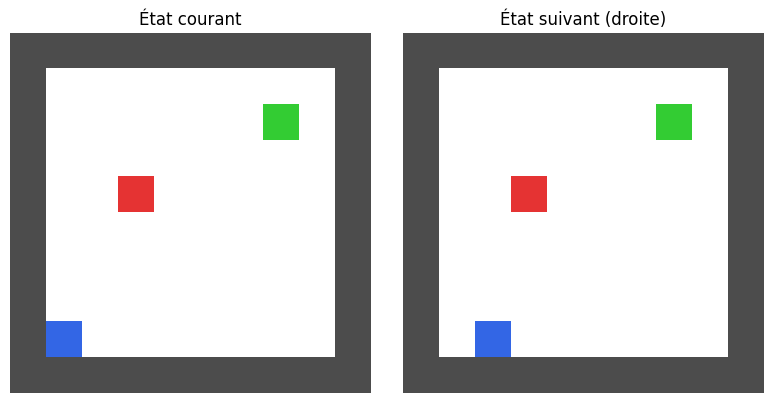

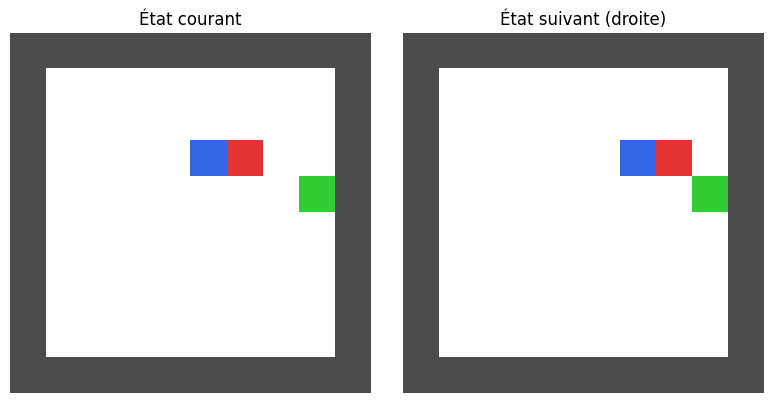

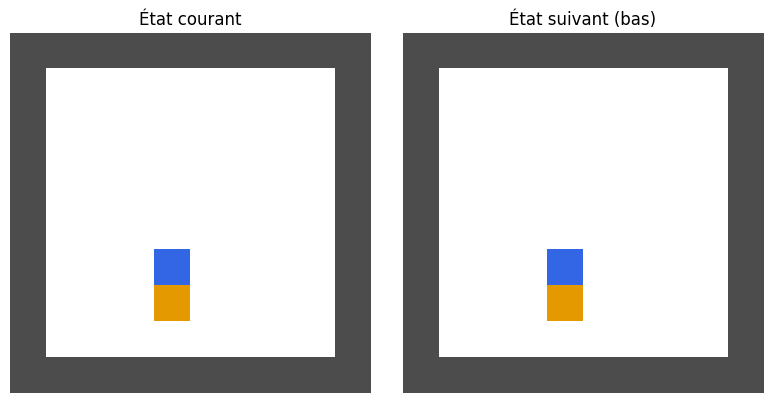

In [22]:
for _ in range(5):
    i = np.random.randint(0, len(observations))
    show_transition(
        observations[i],
        next_obs[i],
        action_name=ACTION_NAMES[actions[i]]
    )

## 💾 Sauvegarde du dataset

On sauvegarde le dataset pour l'utiliser dans le notebook d'entraînement.

In [23]:
np.save("../data/observations_v3.npy", observations)
np.save("../data/actions_v3.npy", actions)
np.save("../data/next_obs_v3.npy", next_obs)

print("Dataset sauvegardé ✔️")

Dataset sauvegardé ✔️


## Bonus — Jeu interactif

Pour explorer le monde manuellement avant d'entraîner le modèle.
Utilise les boutons ↑ ↓ ← → pour déplacer l'agent et pousser la boîte.
Le bouton Reset génère une nouvelle configuration aléatoire.

Note : les notebooks GitHub n'affichent pas les widgets interactifs.
Pour jouer, il faut exécuter le notebook localement.

In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def play():
    env = GridWorld(10)
    out = widgets.Output()

    def render_current():
        with out:
            clear_output(wait=True)
            grid = env.render()
            rgb = grid_to_rgb(grid)
            fig, ax = plt.subplots(figsize=(3, 3))
            ax.imshow(rgb)
            ax.set_title("← ↑ → ↓ pour jouer")
            ax.axis("off")
            plt.tight_layout()
            plt.show()

    btn_haut    = widgets.Button(description="↑")
    btn_bas     = widgets.Button(description="↓")
    btn_gauche  = widgets.Button(description="←")
    btn_droite  = widgets.Button(description="→")
    btn_reset   = widgets.Button(description="Reset", button_style="warning")

    def on_action(action):
        env.step(action)
        render_current()

    btn_haut.on_click(lambda _: on_action(0))
    btn_bas.on_click(lambda _: on_action(1))
    btn_gauche.on_click(lambda _: on_action(2))
    btn_droite.on_click(lambda _: on_action(3))
    btn_reset.on_click(lambda _: (env.reset(), render_current()))

    controls = widgets.VBox([
        widgets.HBox([btn_haut]),
        widgets.HBox([btn_gauche, btn_bas, btn_droite]),
        btn_reset,
    ])

    display(widgets.HBox([controls, out]))
    render_current()

play()